### **Practical 1.8 Auditing & Mitigating a Classifier with Fairlearn**
#### **Responsible AI for Classical Systems**
In this practical you will take a real classifier and:
1. **Measure** how it performs for each group, with honest uncertainty
2. **See** the three fairness families as numbers, and watch the *impossibility result* appear
3. **Mitigate** the disparity three ways, and compare what each one buys and costs

>> **How to use this notebook**: run each cell in order with **Shift + Enter**. Every step has a plain-language explanation first, then the code. Read the explanation, run the code, look at the output, then read the "what this means" note. New to Colab? See the Google Colab guide in the Learning Resources section.

### **Step 0 - Setup**
First, install Fairlearn (the fairness toolkit) and any other required Python packages.

When using a Google Colab notebook, install Fairlearn in a notebook cell with:

```python
!pip install -q fairlearn==0.14.0
```

When using a Jupyter Notebook in VS Code, install the package from the PowerShell terminal with:

```powershell
python -m pip install fairlearn==0.14.0
```

Other required packages can be installed in the same way:

```powershell
python -m pip install numpy
python -m pip install pandas
python -m pip install matplotlib
python -m pip install scikit-learn
```

In [23]:
import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.sparse as sp

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from fairlearn.metrics import(
    MetricFrame, selection_rate, true_positive_rate, false_positive_rate, false_negative_rate, count, demographic_parity_difference, equalized_odds_difference
)
from fairlearn.reductions import(ExponentiatedGradient, DemographicParity, EqualizedOdds)
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.preprocessing import CorrelationRemover

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup complete.")


Setup complete.


### **Step 1: Upload and load the data**

Now we load the **German Credit** dataset, 1,000 real loan applicants, each already labelled a **good** (1) or **bad** (0) credit risk.

In this case, the bank really cared about *creditworthiness*, which nobody can measure directly. The label we actually have, `credit risk`, is a 1994 German bank's "good/bad" rating of applicants. There is no clear record on how it was decided (repayment? an officer's call?).

Download `GermanCredit.csv` from the course site, run the cell, and choose the file when prompted.

In [2]:
df = pd.read_csv("data/GermanCredit.csv")
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [3]:
df.shape

(1000, 21)

#### **Configuration**

The settings below tell the rest of the notebook what to predict and how to split people into groups. They're filled in for German Credit. To use another dataset, change only this cell - and check two things first.

**1. Which outcome is the "positive" one.**

`POSITIVE_LABEL` marks the favourable decision (here, approve/good risk). All the rates below are read against it. Watch the direction: a default, fraud or re-arrest column usually marks the bad event as 1, so the approve decision is 0. Pick the wrong one and every result reads backwards while the code still runs fine. Set it to match the favourable decision.

**2. How the protected attribute is recorded.**

It's rarely clean. In this dataset, sex and marital status share one column (personal_status_sex), so we pull sex out of it. Before you split by any attribute, check:
- Is it ready to use, or buried in another column you have to decode?
- How is it coded - text or numbers (e.g., 1/2)? Are there undocumented or missing values?
- Is it self-reported, or guessed from something like a name or postcode?
- Are the categories fine enough for the groups you care about?

In [4]:
# --- CONFIGURATION (change only this cell for a different dataset) ---
TARGET_COLUMN = "credit_risk" # 1 = good risk, 0 = bad risk
POSITIVE_LABEL = 1            # a positive decision = "approve/good"
SEX_SOURCE_COLUMN = "personal_status_sex"
AGE_COLUMN = "age"
AGE_THRESHOLD = 25
# ---------------------------------------------------------------------

y = (df[TARGET_COLUMN] == POSITIVE_LABEL).astype(int)
is_male = df[SEX_SOURCE_COLUMN].str.startswith("male")
df["sex"] = is_male.map({True: "male", False: "female"})

df["age_group"] = np.where(df[AGE_COLUMN] < AGE_THRESHOLD, "young (<25)", "older (>=25)")

A = df["sex"]
print("Protected groups (sex):")
print(A.value_counts())

Protected groups (sex):
sex
male      690
female    310
Name: count, dtype: int64


> **What this means**: notice the groups are different sizes, far more men than women. Keep that in mind: the smaller group's numbers will be shakier. You will see that in Step 4.

#### **A note on privacy**

Fairness creates a privacy tension: **to check a model for bias, you have to keep the attributes that are most privacy-sensitive**. You can't audit fairness without sex, age and the like, so they can't just be deleted. Four risks, each with its source and what to do:
1. **Keeping protected attributes to audit.** The audit needs them. *Fix:* keep the attributes for *auditing* separate from the features used to *predict*, and restrict access.

2. **Re-identification.** The data, with no name, age + sex + education + credit limit + repayment pattern can still single a person out. De-identified is not anonymous. *Fix:* treat the records as personal data: aggregate or suppress small subgroups before reporting.

3. **The attribute leaks through other columns.** Dropping sex doesn't remove it if other columns encode it ("fairness through unawareness fails"). *Fix:* assume the signal is still there; deletion alone isn't privacy.

4. **Secondary use.** Reusing account data to train an approval model is a purpose the people never agreed to. *Fix:* lawful basis, notice, and retention limits (DISR *Privacy protection & security*).

---

> **NOTE: don't overstate it**: for a simple model on tabular data, attacks that recover whether someone was in the training set are a minor concern. They matter for large models and foundation models.

---

**Base rates** = how often each group is *actually* a good credit risk in the data. This matters a lot: when the two base rates differ, it becomes mathematically impossible to make every fairness measure equal at once (you'll see this in Step 6).

In [5]:
base_rates = pd.Series(y.values,index=A.values).groupby(level=0).mean().round(3)
print("Base rate(proportion good) by group:")
print(base_rates)

Base rate(proportion good) by group:
female    0.648
male      0.723
dtype: float64


#### **Step 2: Train an ordinary baseline model**

We train a completely standard model, nothing fairness-aware. It scales the numbers, turns text categories into numbers (one-hot encoding), and fits a logistic regression. We split the data into a training part (to learn from) and a test part (to evaluate on), so we judge the model on data it hasn't seen.

The point here is to see how an ordinary model treats different groups.

In [6]:
drop_cols = [TARGET_COLUMN, SEX_SOURCE_COLUMN, "sex", "age_group"]
X = df.drop(columns=drop_cols)

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

preprocess = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])
baseline=Pipeline([
    ("preprocess", preprocess),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X, y, A, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
print("Overall accuracy:", round(accuracy_score(y_test, y_pred), 3))

Overall accuracy: 0.733


> **What this means:** that one accuracy number is the trap. It says the model is right about three-quarters of the time *on average*, and tells you nothing about *who* it's right or wrong for. Fairness lives in the breakdown, which we do next.

### **Step 3: Break the results down by group**

`MetricFrame` is Fairlearn's main tool. You hand it your metrics, the true answers, the model's predictions, and the group each person belongs to, and it computes every metric *separately for each group*.

Quick reminder of the rates meaning in this dataset's context:

- **selection_rate**: how often the model says "approve"
- **TPR**: of the people who are truly good risks, how many it correctly approves
- **FPR**: of the people who are truly bad risks, how many it wrongly approves
- **FNR**: of the people who are truly good risks, how many it wrongly rejects

In [7]:
metrics = {
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
    "TPR": true_positive_rate,
    "FPR": false_positive_rate,
    "FNR": false_negative_rate,
    "count": count
}
mf = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
print("Per-group results:")
mf.by_group

Per-group results:


,accuracy,selection_rate,TPR,FPR,FNR,count
sex,,,,,,
female,0.708333,0.718750,0.825397,0.515152,0.174603,96.0
male,0.745098,0.769608,0.857143,0.543860,0.142857,204.0


---

>> **Note**: with only two groups here, the "largest gap" is just the gap between them; with three or more groups it would be the widest difference (highest group - lowest).

---

In [8]:
print("Largest gap between the groups, per metric:")
mf.difference()

Largest gap between the groups, per metric:


accuracy            0.036765
selection_rate      0.050858
TPR                 0.031746
FPR                 0.028708
FNR                 0.031746
count             108.000000
dtype: float64

**A picture of the same thing.** The chart below puts the two groups side by side on three key rates. Bars at different heights = the model behaves differently for the two groups.

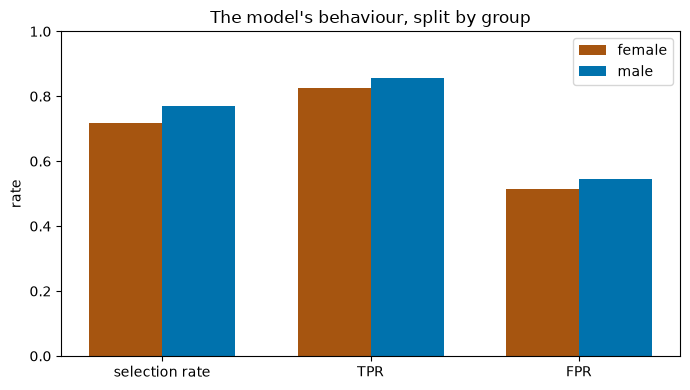

In [9]:
bg = mf.by_group[["selection_rate", "TPR", "FPR"]]
x = np.arange(len(bg.columns)); w = 0.35
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x-w/2,bg.loc["female"],w,label="female",color="#A65510")
ax.bar(x+w/2,bg.loc["male"],w,label="male",color="#0072AD")
ax.set_xticks(x); ax.set_xticklabels(["selection rate", "TPR", "FPR"])
ax.set_ylim(0,1);ax.set_ylabel("rate");ax.legend()
ax.set_title("The model's behaviour, split by group")
plt.tight_layout(); plt.show()

### **Step 4: How sure are we? (small groups are noisy)**

**What's happening:** every rate above is an *estimate* from a sample. The female group is small, so its rates are estimated from few people and could easily be off. We use
**bootstrapping**: we resample each group's data with replacement thousands of times, recompute the rate each time, and see how much it wobbles. The wobble gives us a **95%
confidence interval**, a range the true rate is plausibly in.

**Why you must do this:** a gap between two point numbers can vanish once you see the ranges around them.

In [12]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=2000, seed=RANDOM_STATE):
    """Compute a 95%bootstrap confidence interval for a rate within one group."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    n = len(y_true); est = []
    for _ in range(n_boot):
        idx = rng.integers(0,n,n)
        try: est.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception: pass
    return np.percentile(est, [2.5, 97.5])

A_arr = np.asarray(A_test); y_arr = np.asarray(y_test)
print("Selection rate with 95% confidence interval, by group:\n")
for g in np.unique(A_arr):
    m = A_arr == g
    p = selection_rate(y_arr[m], y_pred[m])
    lo, hi = bootstrap_ci(y_arr[m], y_pred[m], selection_rate)
    print(f"{g:>8} (n={m.sum():4d}): {p:.3f} 95% CI [{lo:.3f}, {hi:.3f}]")

Selection rate with 95% confidence interval, by group:

  female (n=  96): 0.719 95% CI [0.625, 0.812]
    male (n= 204): 0.770 95% CI [0.711, 0.824]


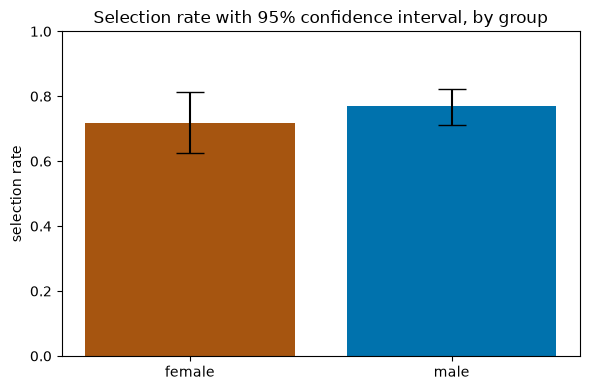

In [13]:
# Same thing as a plot: the bar is the estimate, the whisker is the uncertainty
groups = np.unique(A_arr); pts, los, his = [], [], []
for g in groups:
    m = A_arr == g
    p = selection_rate(y_arr[m], y_pred[m])
    lo, hi = bootstrap_ci(y_arr[m], y_pred[m], selection_rate)
    pts.append(p); los.append(p -lo); his.append(hi - p)
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(groups, pts, yerr=[los, his], capsize=10, color=["#A65510", "#0072AD"])
ax.set_ylabel("selection rate"); ax.set_ylim(0,1)
ax.set_title("Selection rate with 95% confidence interval, by group")
plt.tight_layout(); plt.show()


**How to read the error bars:** each bar shows a 95% confidence interval, the range the group's true rate plausibly sits in. Compare the two ranges on the vertical axis:

- **Clearly separated** (no shared values) -> strong evidence the groups really differ on this metric.
- **Overlapping** -> you can't claim a difference from this check. That doesn't mean the groups are equal; it means the gap is *unconfirmed* - there may be no gap, or a real one the sample is too small to show. A small group gives wide error bars, so its gaps are the easiest to over-read.

So overlap only lets you *withhold* a claim, it never confirms the groups are equal. For a firm call on an overlapping gap, test the difference directly (e.g., a confidence interval on the gap itself).

(For this dataset, look closely: the female and male intervals overlap, so the sex gap here is *not* established. Treat it as unconfirmed, not as proof of fairness.)

### **Step 5: The three fairness families, as single numbers**

We have discussed in the course three families of fairness. Fairlearn can summarise each as one number that measures the *gap between groups*. Bigger number = less equal on that definition.

- **Demographic parity difference (DPD)** -> *independence*: are the two groups approved at the same rate?
- **Equalized odds difference (EOD)** -> *separation*: do the two groups have the same error rates?
- *Sufficiency / calibration* -> read off PPV per group from the table; we focus on the two above.

In [14]:
dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=A_test)
eod = equalized_odds_difference(y_test, y_pred, sensitive_features=A_test)
print(f"Demographic parity difference (independence): {dpd:.3f}")
print(f"Equalized odds difference (separability): {eod:.3f}")

Demographic parity difference (independence): 0.051
Equalized odds difference (separability): 0.032


#### **So what number are we aiming for?**

A natural question: **do we want these at zero?**

- For **one** family on its own, **zero means "no gap"** on that definition, lower is more equal. In that narrow sense, zero is the goal.

- But you **can't get all families to zero at once.** When groups have different base rates (ours do), pushing DPD toward zero usually pushes EOD up, and the reverse. You'll see this in Step 6, it's the **impossibility result**, not a bug.

- And **zero isn't always desirable.** Forcing equal approval rates (DPD = 0) can mean approving weaker applicants in one group, or rejecting strong ones in another, to match the rates. Whether that's right depends on the setting.

**So the target isn't "make everything zero."** It's: decide which family matters most for this decisiom, reduce that one as far as you sensibly can, and report the others and what they cost.

There's no universal threshold, choosing the target is a judgement you make for each decision.

### **Step 6: Watch the impossibility appear**

We'll now try three ways to make the model fairer, and collect every attempt into one table. Watch what happens: as we shrink one disparity, another moves.

In [15]:
results = []
def record(name, y_true, y_pred, A):
    results.append({
        "approach": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "demographic_parity": demographic_parity_difference(y_true, y_pred, sensitive_features=A),
        "equalized_odds": equalized_odds_difference(y_true, y_pred, sensitive_features=A)
    })
record("baseline", y_test, y_pred, A_test)
pd.DataFrame(results).set_index("approach").round(3)

,accuracy,demographic_parity,equalized_odds
approach,,,
baseline,0.733,0.051,0.032


#### **Three places to intervene**

There are exactly **three points** in the pipeline where you can act on fairness, and we will try one fix at each:

| Where | When it acts | Tool we use | Aims at |
| ----- | ------------ | ----------- | ------- |
| **Pre-processing** | *before* training - fix the data | `CorrelationRemover` | independence (DPD) |
| **In-processing** | *during* training - constrain the model | `ExponentiatedGradient` | independence **or** separation |
| **Post-processing** | *after* training - adjust the decisions | `ThresholdOptimizer` | independence (DPD) |

Keep this map in mind as we go: each fix lives at a different stage, and each comes with a different cost. We collect every attempt into one table and compare them at the end.

### **Step 7: Fix attempt 1, clean the data before training (pre-processing)**

**What's happening:** the earliest place to intervene is the *data itself*, before any model sees it. The idea: scrub out the parts of the other features that secretly track the protected attribute, so the model can't lean on them. Fairlearn's `CorrelationRemover` does this, it removes the correlation between the sensitive feature and the rest.

This connects straight to a Week 1 lesson: simply deleting "sex" usually isn't enough, because other columns (job, housing, and so on) can stand in for it. Pre-processing tries to remove that hidden signal too.

In [18]:
# 1. Encode the features to a numeric matrix
X_tr_enc = preprocess.fit_transform(X_train)
X_te_enc = preprocess.transform(X_test)
if sp.issparse(X_tr_enc):
    X_tr_enc = X_tr_enc.toarray(); X_te_enc = X_te_enc.toarray()

# 2. Put the sensitive attribute (as 0/1) in front, so that the correlation remover can remove it from the other features
s_tr = (A_train == "male").astype(int).values.reshape(-1,1)
s_te = (A_test == "male").astype(int).values.reshape(-1,1)
X_tr_aug = np.hstack([s_tr, X_tr_enc])
X_te_aug = np.hstack([s_te, X_te_enc])

# 3. Remove the correlation with the sensitive attribute
cr = CorrelationRemover(sensitive_feature_ids=[0])
X_tr_clean = cr.fit_transform(X_tr_aug)
X_te_clean = cr.transform(X_te_aug)

# 4. Train an ordinary model on the cleaned data
pre_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
pre_model.fit(X_tr_clean, y_train)
y_pre = pre_model.predict(X_te_clean)

record("preprocessing", y_test, y_pre, A_test)
print("accuracy:", round(accuracy_score(y_test, y_pre), 3),
      "demographic parity:", round(demographic_parity_difference(y_test, y_pre, sensitive_features=A_test), 3),
      "equalized odds:", round(equalized_odds_difference(y_test, y_pre, sensitive_features=A_test), 3))

accuracy: 0.747 demographic parity: 0.005 equalized odds: 0.054


**What this means:** cleaning the data pulls the approval-rate gap (DPD) down a long way, without ever touching the model or the decision rule. It's attractive because it fixes the problem at the source. The catch: it can only remove what it can *see* as correlation, and it still doesn't guarantee the other fairness families. It's one tool, not a cure.

### **Step 8: Fix attempt 2, constrain the model during training (in-processing)**

**What's happening:** instead of training a normal model and hoping it's fair, we tell the training process: *get the best accuracy you can, but keep the approval rates close between groups*. `ExponentiatedGradient` with a `DemographicParity` constraint does this. This is called **in-processing**, the fix happens *during* learning.

In [19]:
X_tr_enc = preprocess.fit_transform(X_train)
X_te_enc = preprocess.transform(X_test)

eg = ExponentiatedGradient(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), constraints=DemographicParity())
eg.fit(X_tr_enc, y_train, sensitive_features=A_train)
y_eg = eg.predict(X_te_enc)
record("exponentiated_gradient", y_test, y_eg, A_test)
print("accuracy:", round(accuracy_score(y_test, y_eg), 3),
      "demographic parity:", round(demographic_parity_difference(y_test, y_eg, sensitive_features=A_test), 3),
      "equalized odds:", round(equalized_odds_difference(y_test, y_eg, sensitive_features=A_test), 3))

accuracy: 0.753 demographic parity: 0.01 equalized odds: 0.072


**What this means:** the constraint pushes **DPD** (independence) right down, good. But it makes **no promise** about EOD (separation), and you'll see EOD didn't improve. Fixing one family doesn't fix the others. That's the impossibility result, not a coding mistake.

### **Step 9: Fix attempt 3, adjust the decisions afterwards (post-processing)**

**What's happening:** here we leave the trained model completely alone and instead change *how its scores become yes/no decisions*, by picking a **different cut-off (threshold) for each group** so the approval rates match. `ThresholdOptimizer` does this. It's called **post-processing**, the fix happens *after* training.

In [20]:
to = ThresholdOptimizer(
    estimator=baseline, constraints="demographic_parity", predict_method="predict_proba",prefit=True
)
to.fit(X_train, y_train, sensitive_features=A_train)
y_to = to.predict(X_test, sensitive_features=A_test)
record("postprocessing", y_test, y_to, A_test)
print("accuracy:", round(accuracy_score(y_test, y_to), 3),
      "demographic parity:", round(demographic_parity_difference(y_test, y_to, sensitive_features=A_test), 3),
      "equalized odds:", round(equalized_odds_difference(y_test, y_to, sensitive_features=A_test), 3))

accuracy: 0.743 demographic parity: 0.011 equalized odds: 0.067


**What this means, and a caution:** this works on *any* existing model without retraining, which is handy. But it uses a **different threshold for each group**, that is, *explicitly* treating people differently based on a protected attribute. Transparent, but legally and ethically sensitive, and something you must be able to justify.

### **Step 10: The same in-processing tool, aimed at a different family**

So far every fix aimed at **independence** (equal approval rates, DPD). watch what happens when we aim the *same* in-processing tool at **separation** instead (equal error rates, EOD), by swapping the constraint to `EqualizeOdds`.

In [21]:
eg_eo = ExponentiatedGradient(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), constraints=EqualizedOdds())
eg_eo.fit(X_tr_enc, y_train, sensitive_features=A_train)
y_eg_eo = eg_eo.predict(X_te_enc)
record("in-processing (EO)", y_test, y_eg_eo, A_test)
print("accuracy:", round(accuracy_score(y_test, y_eg_eo), 3),
      "demographic parity:", round(demographic_parity_difference(y_test, y_eg_eo, sensitive_features=A_test), 3),
      "equalized odds:", round(equalized_odds_difference(y_test, y_eg_eo, sensitive_features=A_test), 3))

accuracy: 0.733 demographic parity: 0.009 equalized odds: 0.08


**The key result.** Compare this row with the demographic-parity rows in the table below. Aiming at separation gets **EOD** down but lets **DPD** climb; aiming at independence did the opposite. You can't have both at once, so you have to *choose* which one matters for the decision in front of you. That choice is the real work, a judgement you make for each case, made on the values at stake rather than read off a formula.

### **Step 11: Compare everything**

**What's happening:** one table, then one picture. Each row ia an approach; the columns are accuracy and the two disparities. We're looking for whether *any* approach wins on everything (spoiler: none does).

In [22]:
res = pd.DataFrame(results).set_index("approach").round(3)
res

,accuracy,demographic_parity,equalized_odds
approach,,,
baseline,0.733,0.051,0.032
preprocessing,0.747,0.005,0.054
exponentiated_gradient,0.753,0.010,0.072
postprocessing,0.743,0.011,0.067
in-processing (EO),0.733,0.009,0.080


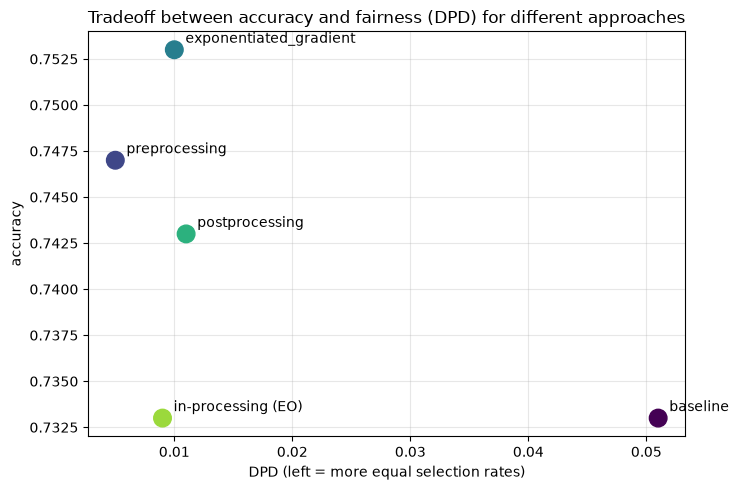

In [ ]:
# Picture: each approach as a point. Left = more equal selection (lower DPD); upper = more accurate (higher accuracy)
fig, ax = plt.subplots(figsize=(7.5,5))
palette = cm.viridis(np.linspace(0,0.85,len(res)))
ax.scatter(res["demographic_parity"], res["accuracy"], s=160, color=palette, zorder=3)
for (name, r), col in zip(res.iterrows(), palette):
    ax.annotate(name, (r["demographic_parity"], r["accuracy"]), xytext=(8,5), textcoords="offset points", fontsize=10)
ax.set_xlabel("DPD (left = more equal selection rates)"); ax.set_ylabel("accuracy")
ax.set_title("Tradeoff between accuracy and fairness (DPD) for different approaches")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**What this means:** no point sits best on every axis. The mitigations move left (more equal selection) but, if you check the table, their **EOD goes up** they bought independence by giving up some separation. **There is no neutral choice.**

---

**Exercise 1 - a different protected attribute.** Re-audit the baseline predictions using **age_group** (young < 25 vs older) instead of sex. Is the story the same, or worse?

In [27]:
# Answer 1
A_age = df.loc[A_test.index, "age_group"]
mf_age = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred, sensitive_features=A_age)
print(mf_age.by_group)
print("\nDPD (age):", round(demographic_parity_difference(y_test, y_pred, sensitive_features=A_age), 3))

              accuracy  selection_rate       TPR       FPR       FNR  count
age_group                                                                  
older (>=25)  0.758893        0.770751  0.864130  0.521739  0.135870  253.0
young (<25)   0.595745        0.659574  0.730769  0.571429  0.269231   47.0

DPD (age): 0.111


**Exercise 2 - change the constraint.** Re-run Step 7's `ExponentiatedGradient`, but with `EqualizedOdds()` instead of `DemographicParity()`. Which disparity drops this time?

In [28]:
# Answer 2
eg2 = ExponentiatedGradient(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), constraints=EqualizedOdds())
eg2.fit(X_tr_enc, y_train, sensitive_features=A_train)
y_eg2 = eg2.predict(X_te_enc)
print("DPD:", round(demographic_parity_difference(y_test, y_eg2, sensitive_features=A_test), 3))
print("EOD:", round(equalized_odds_difference(y_test, y_eg2, sensitive_features=A_test), 3))

DPD: 0.015
EOD: 0.037


**Exercise 3 - intersectionality.** Build a group label that combines **sex x age_group** (four subgroups) and look at `selection_rate` for each. Which corner is worst-served? (This week warned harm often hides where two axes meet.)

In [29]:
# Answer 3
A_inter = df.loc[A_test.index, "sex"] + " / " + df.loc[A_test.index, "age_group"]
mf_inter = MetricFrame(metrics={"selection_rate": selection_rate, "count": count}, y_true=y_test, y_pred=y_pred, sensitive_features=A_inter)
print(mf_inter.by_group)

                       selection_rate  count
sensitive_feature_0                         
female / older (>=25)        0.787879   66.0
female / young (<25)         0.566667   30.0
male / older (>=25)          0.764706  187.0
male / young (<25)           0.823529   17.0


**Exercise 4 - written judgement (no code).** In three or four sentences: which mitigation would uou recommend for this lending setting, and what are you giving up by choosing it? Tie your answer to *who bears the harm* of a wrong decision.

**Answer**

Based on the notebook results, I would recommend preprocessing for this lending scenario. It achieves the lowest demographic parity difference (0.005) while also improving accuracy over the baseline (0.747 vs. 0.733), giving a good balance between fairness and predictive performance. The trade-off is that its equalized odds disparity is slightly higher, meaning some groups may still experience different false positive or false negative rates. In a lending setting, these errors matter because a false negative unfairly denies a qualified applicant access to credit, while a false positive may expose the lender to greater financial risk, so the chosen mitigation should balance fairness for applicants with the lender's need to manage risk.


### **Recap**

- Fairness is built from **per-group** results, and every rate is an **estimate** with uncertainty, check the intervals.

- The **three families** answer different questions and **can't all be zero** when base rates differ.

- You can fix things **before, during, or after** training, and each fix **trades one thing for another**.

- No metric repairs a **bad target**, validity comes first.